<a href="https://colab.research.google.com/github/Hitorido/Machine-Learning-Activity/blob/main/Santos_Activity02_DataAnalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
file_path = "student-mat.csv"

In [ ]:
# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "danielcorredera/student-mat-csv",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

In [10]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/danielcorredera/student-mat-csv/versions/1/student-mat.csv', delimiter=';')

#Descriptive Analytics

In [ ]:
df.describe()

In [ ]:
print(df.columns)

In [11]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [20]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [24]:
print('number pf rpws: ', df.shape[0])
print('number of columns', df.shape[1])

number pf rpws:  395
number of columns 33


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [13]:
print(df['sex'].value_counts())

sex
F    208
M    187
Name: count, dtype: int64


In [14]:
print(df['school'].value_counts())

school
GP    349
MS     46
Name: count, dtype: int64


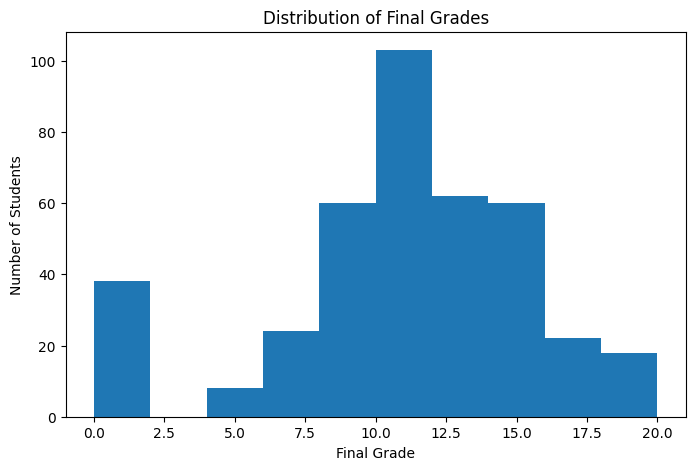

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df['G3'], bins = 10)

plt.xlabel('Final Grade')
plt.ylabel('Number of Students')
plt.title('Distribution of Final Grades')
plt.show()

In [16]:
df.groupby("sex")["G3"].mean()

,G3
sex,
F,9.966346
M,10.914439


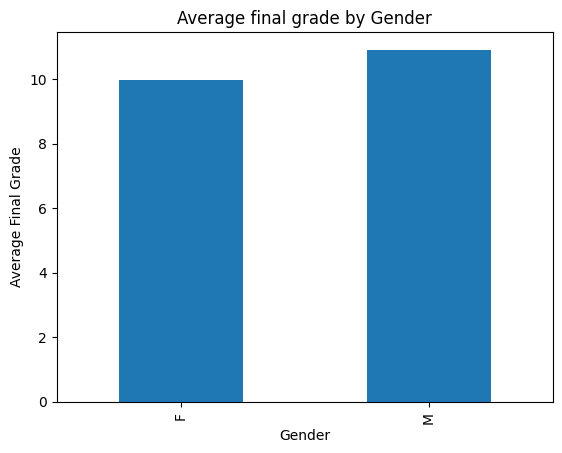

In [19]:
df.groupby("sex")["G3"].mean().plot(kind="bar")

plt.xlabel('Gender')
plt.ylabel('Average Final Grade')
plt.title('Average final grade by Gender')
plt.show()

#Diagnostic Analytics

In [21]:
df.groupby("studytime")["G3"].mean()

,G3
studytime,
1,10.047619
2,10.171717
3,11.400000
4,11.259259


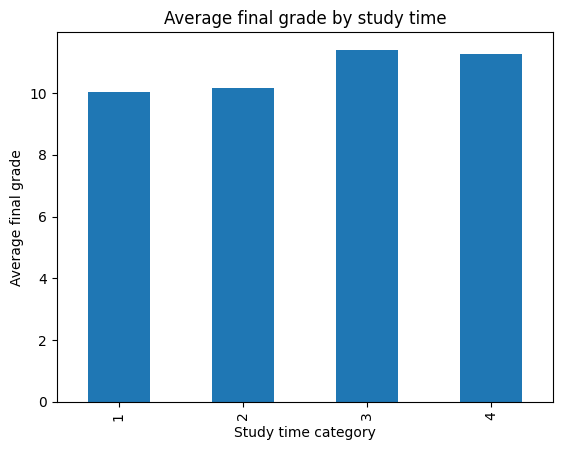

In [23]:
df.groupby("studytime")["G3"].mean().plot(kind="bar")

plt.xlabel('Study time category')
plt.ylabel('Average final grade')
plt.title('Average final grade by study time')
plt.show()

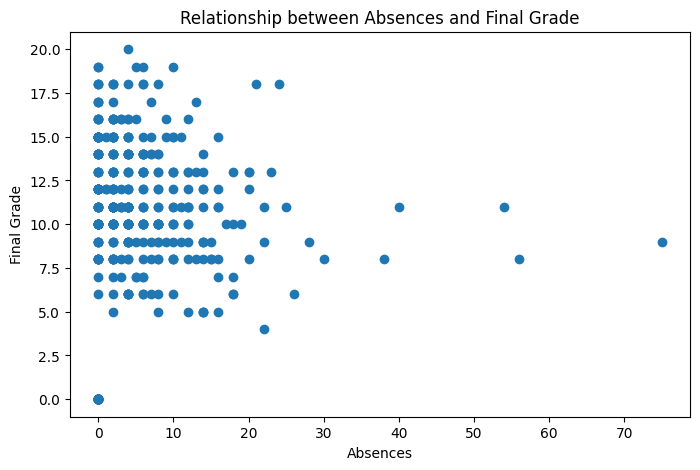

In [27]:
plt.figure(figsize=(8,5))
plt.scatter(df["absences"], df["G3"])

plt.xlabel('number of absences')
plt.ylabel('final grades')
plt.title('absences vs final grade')
plt.show()

In [28]:
print(df["absences"].corr(df["G3"]))

0.03424731615006931


#Predictive Analytics

In [30]:
df["pass"] = (df["G3"]>=10).astype(int)

In [31]:
print(df["pass"].value_counts)

<bound method IndexOpsMixin.value_counts of 0      0
1      0
2      1
3      1
4      1
      ..
390    0
391    1
392    0
393    1
394    0
Name: pass, Length: 395, dtype: int64>


In [34]:
features = [
    'age',
    'studytime',
    'failures',
    'G1',
    'G2'
]

x = df[features]
y = df["pass"]

In [35]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
    )
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [40]:
y_pred = model.predict(x_test)

print(y_pred)

[1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 0 0 0 1 1 0 1 1 1 1 1 0 0 0 0 1 1 1 0 0
 1 1 0 0 0 1 1 1 0 1 1 1 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1 0 1 1 0 1 0 1 1 0
 1 1 0 1 1]


In [41]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8860759493670886


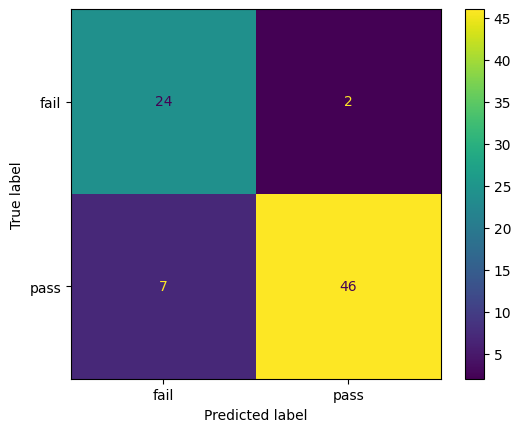

Student pass/fai l confusion matrix
[[24  2]
 [ 7 46]]


In [43]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['fail','pass'])
disp.plot()
plt.show()

print("Student pass/fai l confusion matrix")
print(cm)